In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [13]:
values = pd.read_csv("values.csv")
labels = pd.read_csv("labels.csv")

In [14]:
merged_data = pd.merge(values,labels, on = "patient_id")

In [15]:
data = pd.DataFrame(merged_data)

In [16]:
data.head(5)

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [17]:
data.drop(columns = "patient_id", inplace = True)

In [18]:
data = pd.get_dummies(data, columns=["thal"], drop_first=False)

In [19]:
# Observation:
# patient_id is just a random ID with no medical meaning, and thal
# is a text column (normal, fixed_defect, reversible_defect) that
# models can't read directly.

# Decision:
# I dropped patient_id and used one-hot encoding on thal.

# Reason:
# patient_id doesn't help predict heart disease, so keeping it could
# confuse the model. One-hot encoding turns thal into numbers (0/1)
# so the model can actually use it.

In [20]:
x = data.drop(columns = "heart_disease_present")
y = data["heart_disease_present"]

In [21]:
data["oldpeak_eq_st_depression"].unique()

array([0. , 1.6, 4.2, 2.6, 0.6, 3.4, 0.4, 0.2, 3.8, 0.9, 1.4, 0.1, 0.3,
       2.3, 1.5, 3. , 2. , 1. , 3.1, 2.5, 0.8, 2.4, 1.8, 1.9, 2.8, 1.2,
       0.5, 2.2, 1.3, 1.1, 0.7, 3.2, 5.6, 6.2])

In [22]:
continous_cols = [ "resting_blood_pressure", "serum_cholesterol_mg_per_dl", "oldpeak_eq_st_depression", "age", "max_heart_rate_achieved" ] 

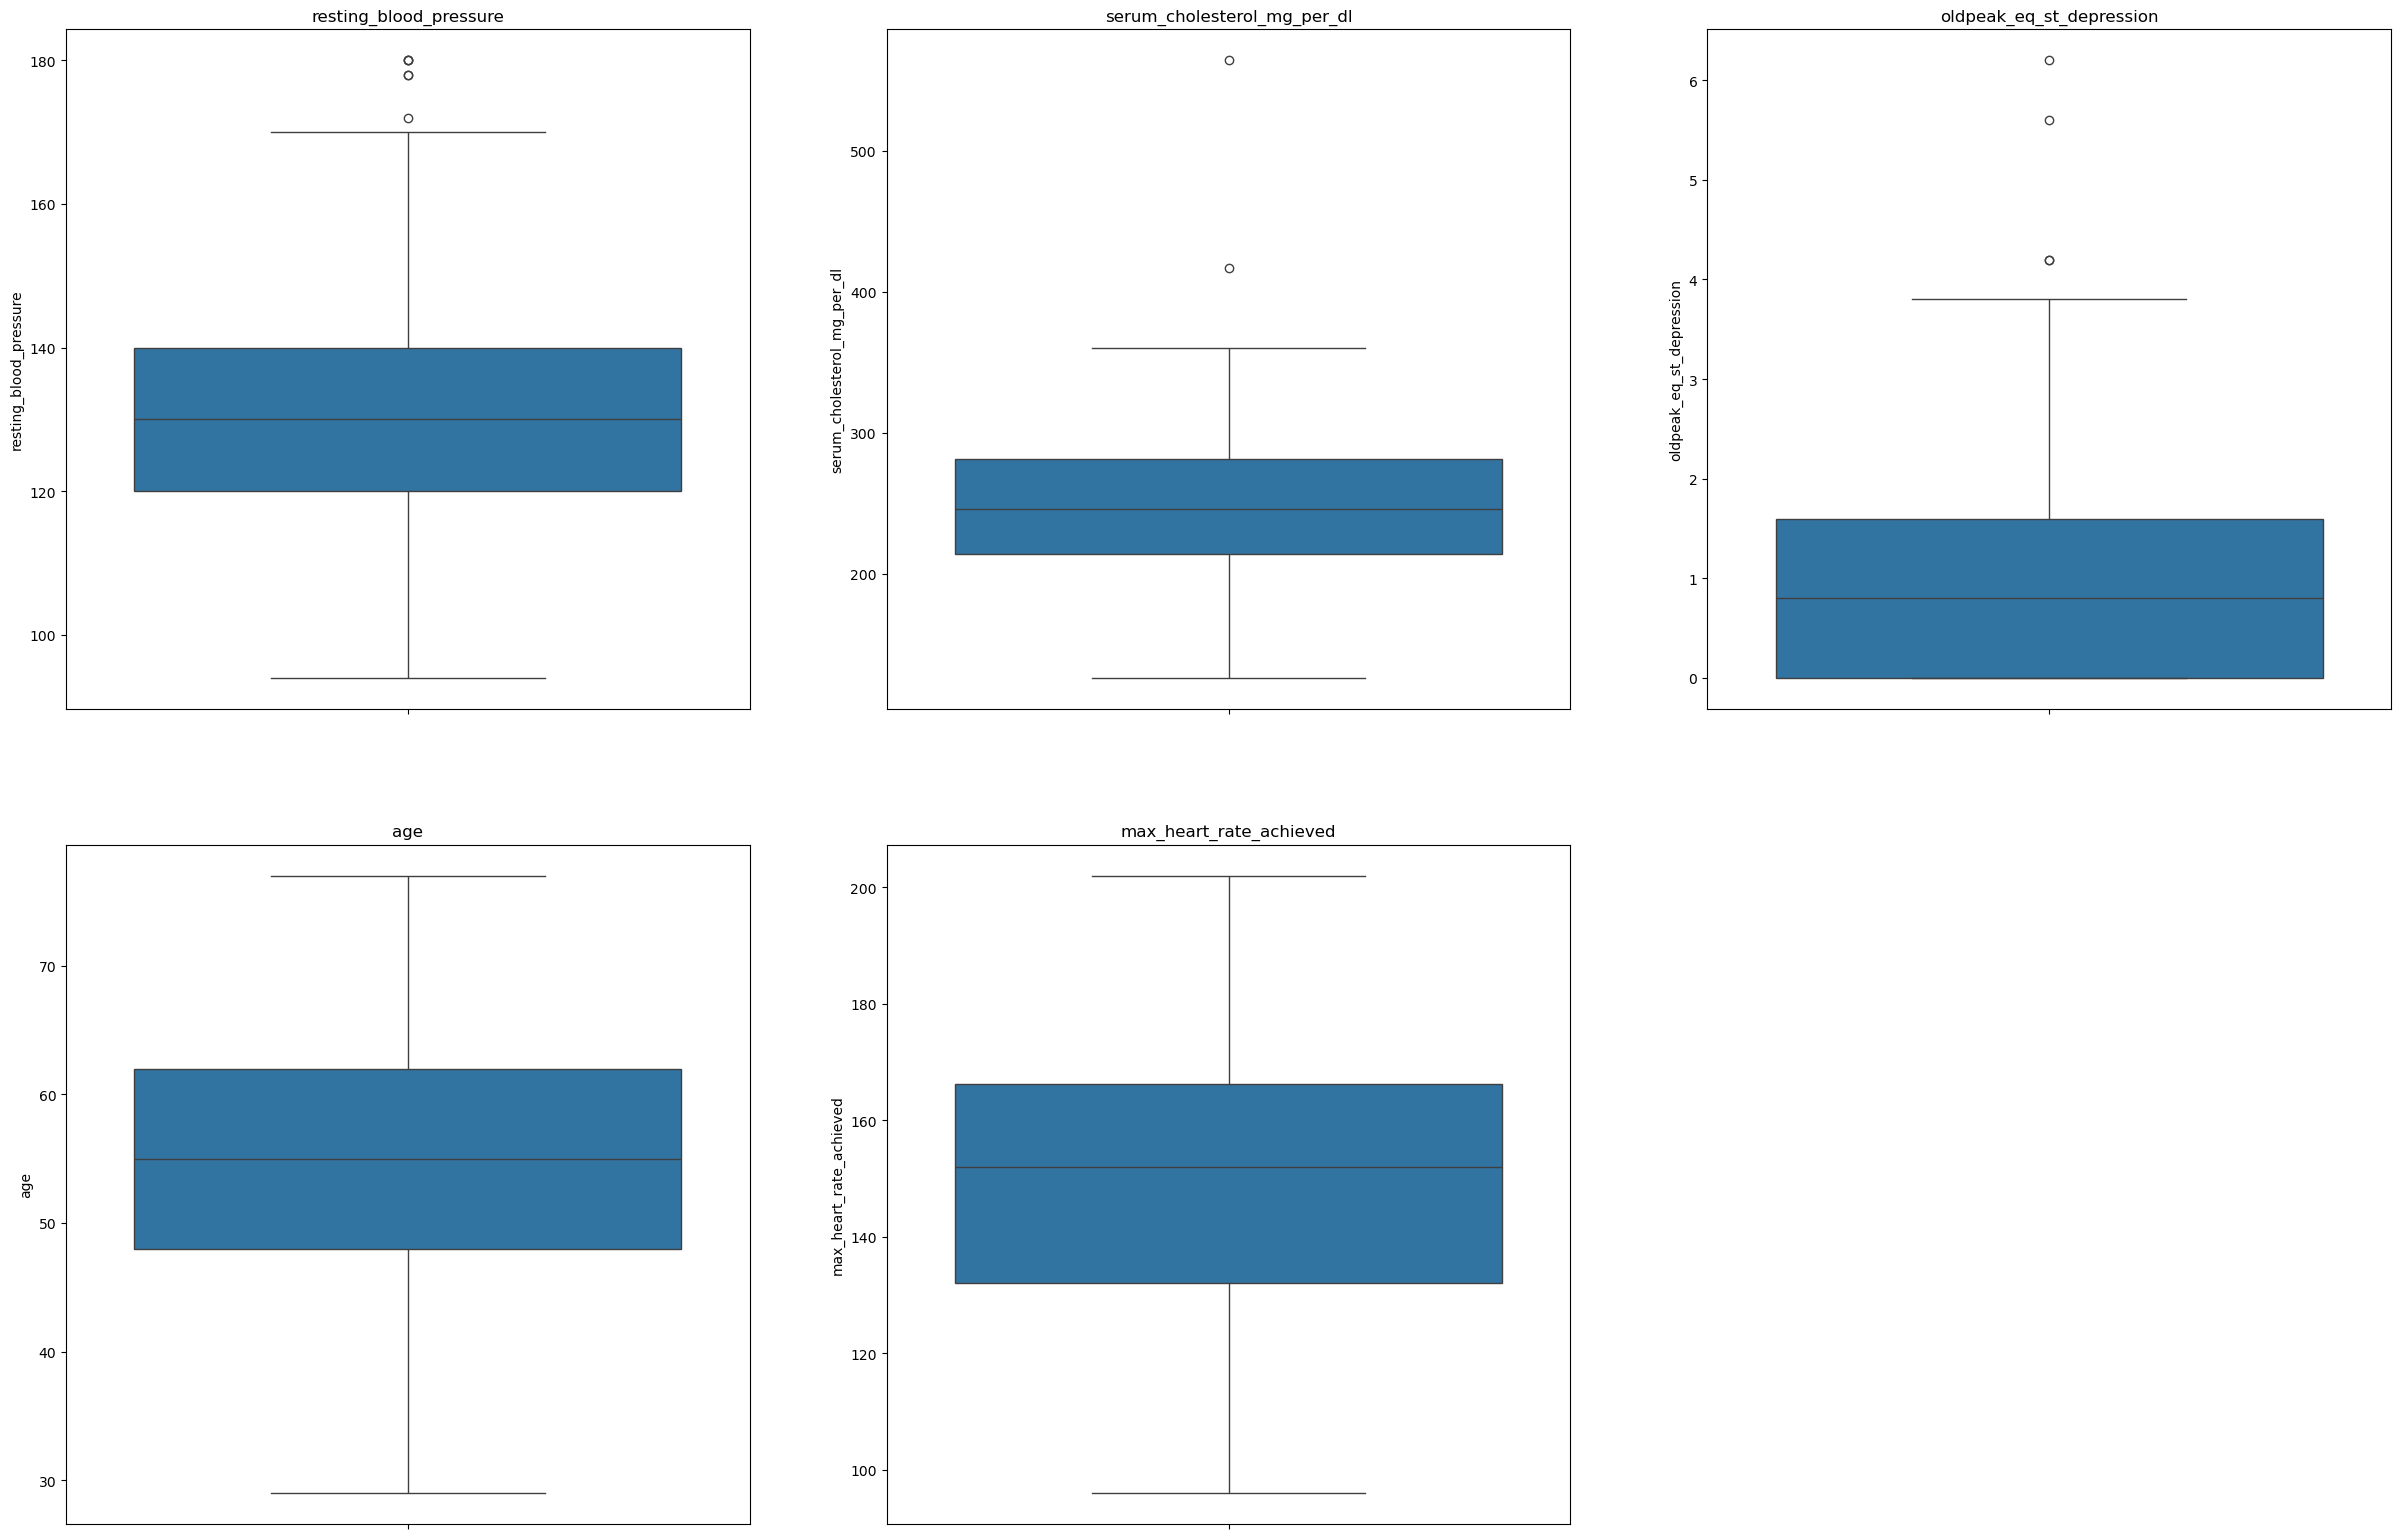

In [23]:
plt.figure(figsize = (30,30))
for i, col in enumerate(continous_cols,1):
    plt.subplot(3,3,i)
    sns.boxplot(y = data[col])
    plt.title(col)
plt.show()

    

In [24]:
outliers_col = ["resting_blood_pressure", "serum_cholesterol_mg_per_dl", "oldpeak_eq_st_depression"]
for col in outliers_col:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    data[col] = data[col].clip(lower= lower, upper = upper)
    

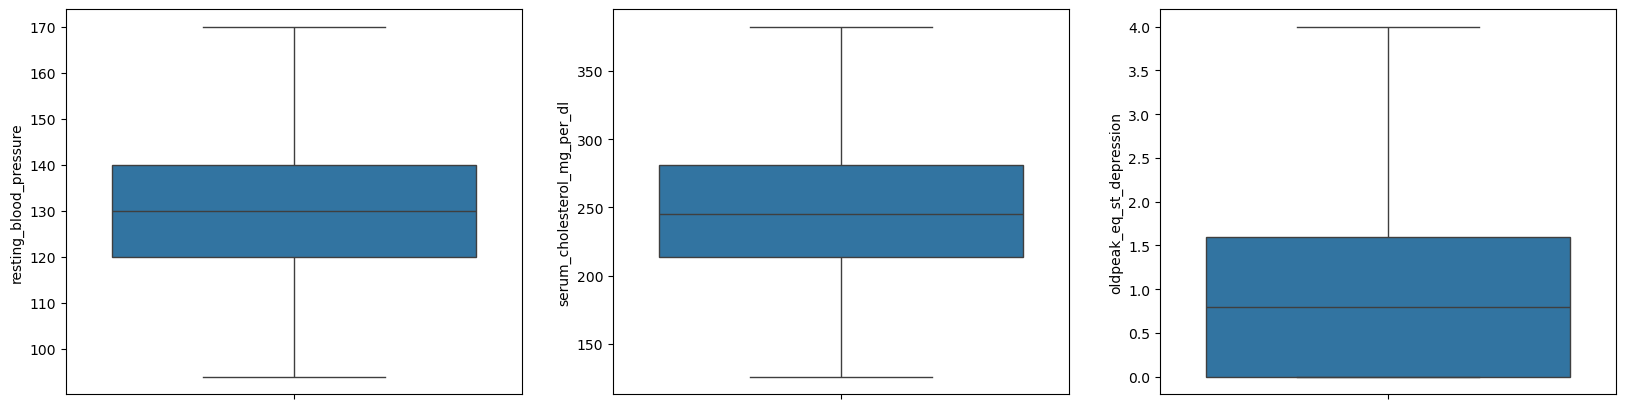

In [25]:
plt.figure(figsize = (20,5))
for i, col in enumerate(outliers_col,1):
    plt.subplot(1,3,i)
    sns.boxplot(y = data[col])
plt.show()

In [26]:
# Observation:
# Some numerical features contain outliers.

# Decision:
# I used the IQR method with clipping instead of removing rows.

# Reason:
# Removing rows may lead to loss of important information. Clipping reduces
# the impact of extreme values while keeping all observations in the dataset.

In [27]:
data.isnull().sum()

slope_of_peak_exercise_st_segment       0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
thal_fixed_defect                       0
thal_normal                             0
thal_reversible_defect                  0
dtype: int64

In [28]:
# Observation:
# No missing values found in the dataset.

# Decision:
# No need to fill or remove any rows.

# Reason:
# Clean data lets us go straight to analysis without extra cleaning steps.

<Axes: >

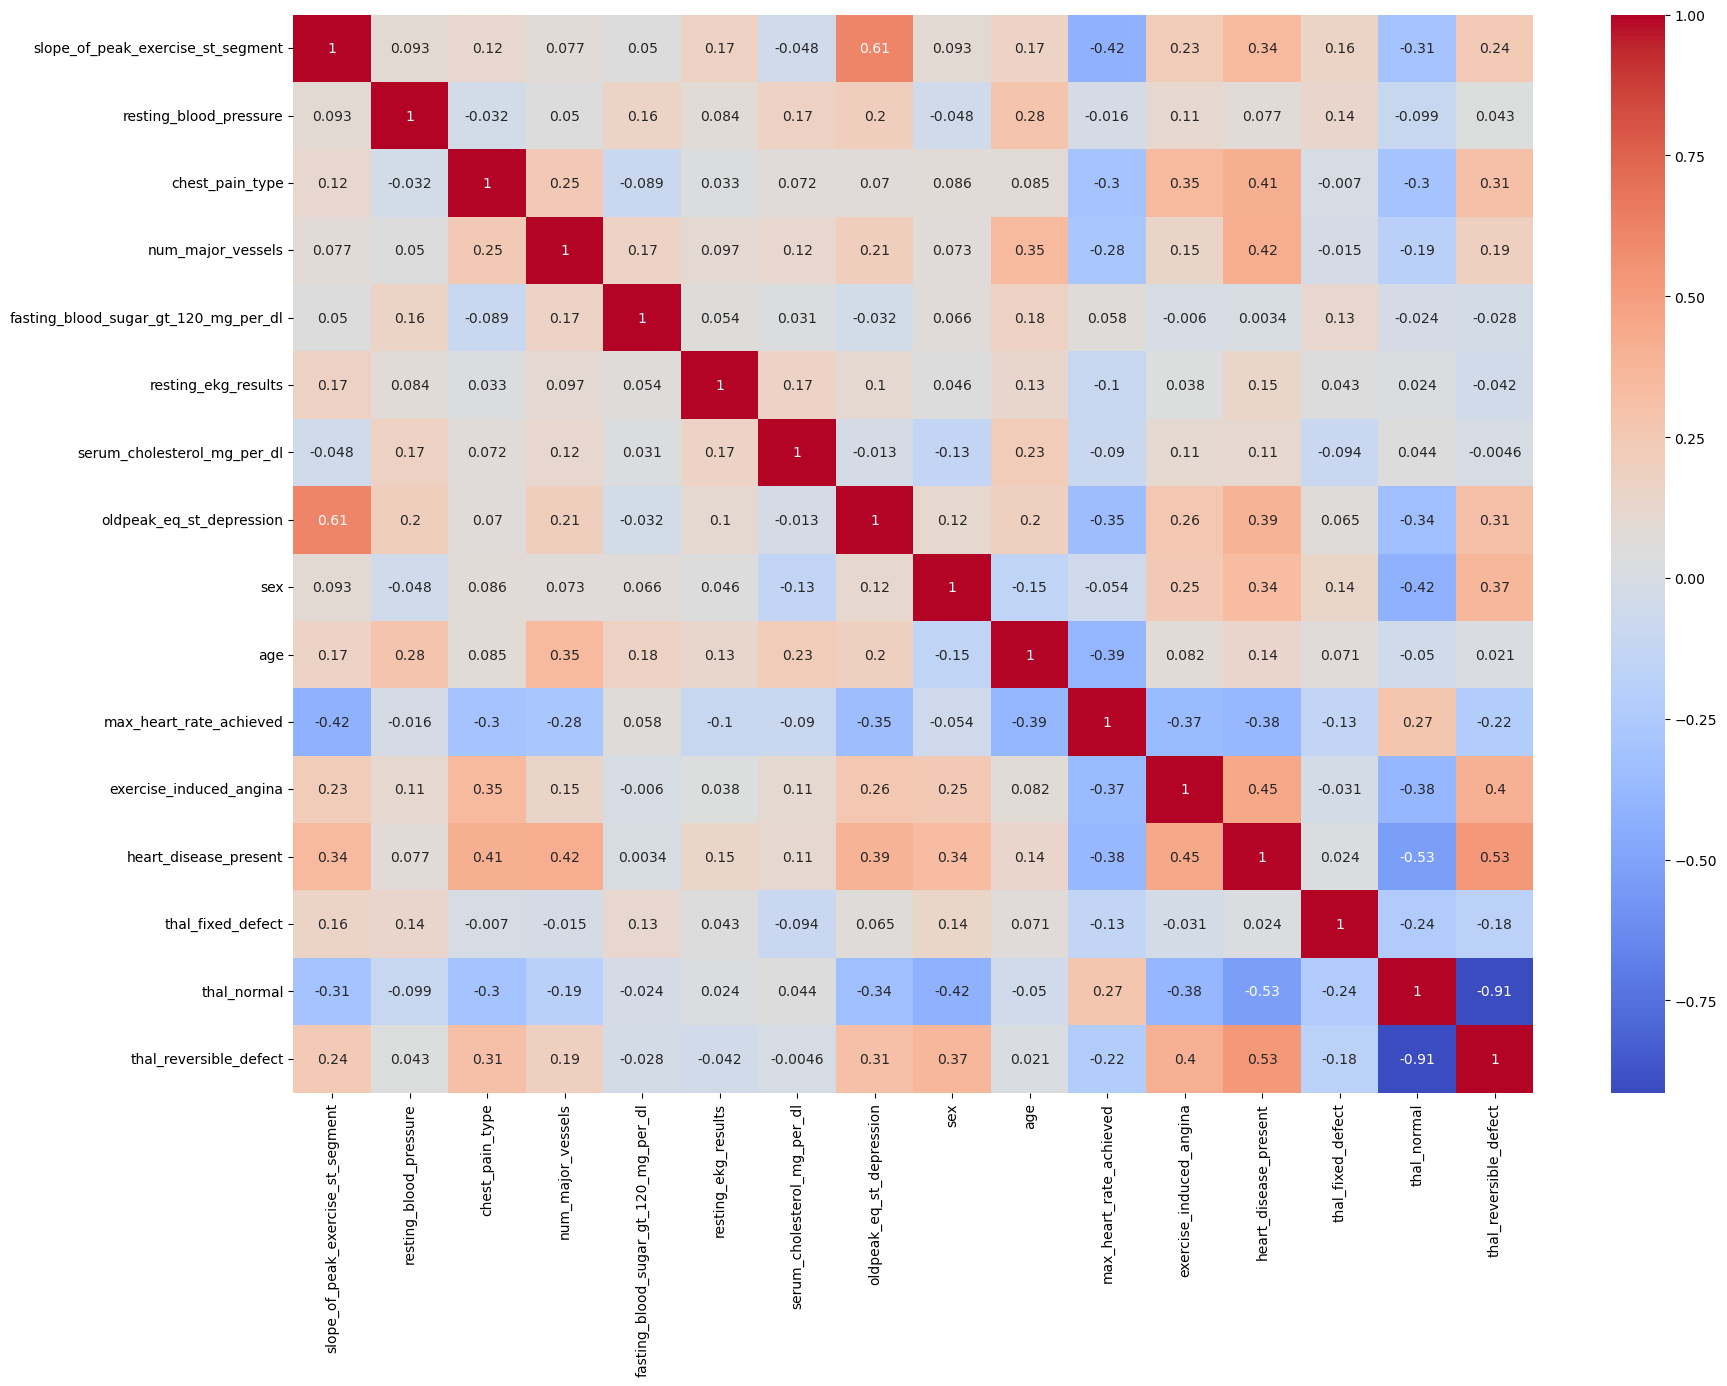

In [29]:
plt.figure(figsize= (20,14))
sns.heatmap(data = data.corr(numeric_only = True), annot = True, cmap = "coolwarm")

In [30]:
# Observation:
# num_major_vessels, exercise_induced_angina, oldpeak_eq_st_depression,
# and thal show the strongest relation to heart disease.

# Decision:
# I kept all features instead of manually removing any.

# Reason:
# Random Forest feature importance is more reliable than the heatmap alone
# for deciding which features actually matter.

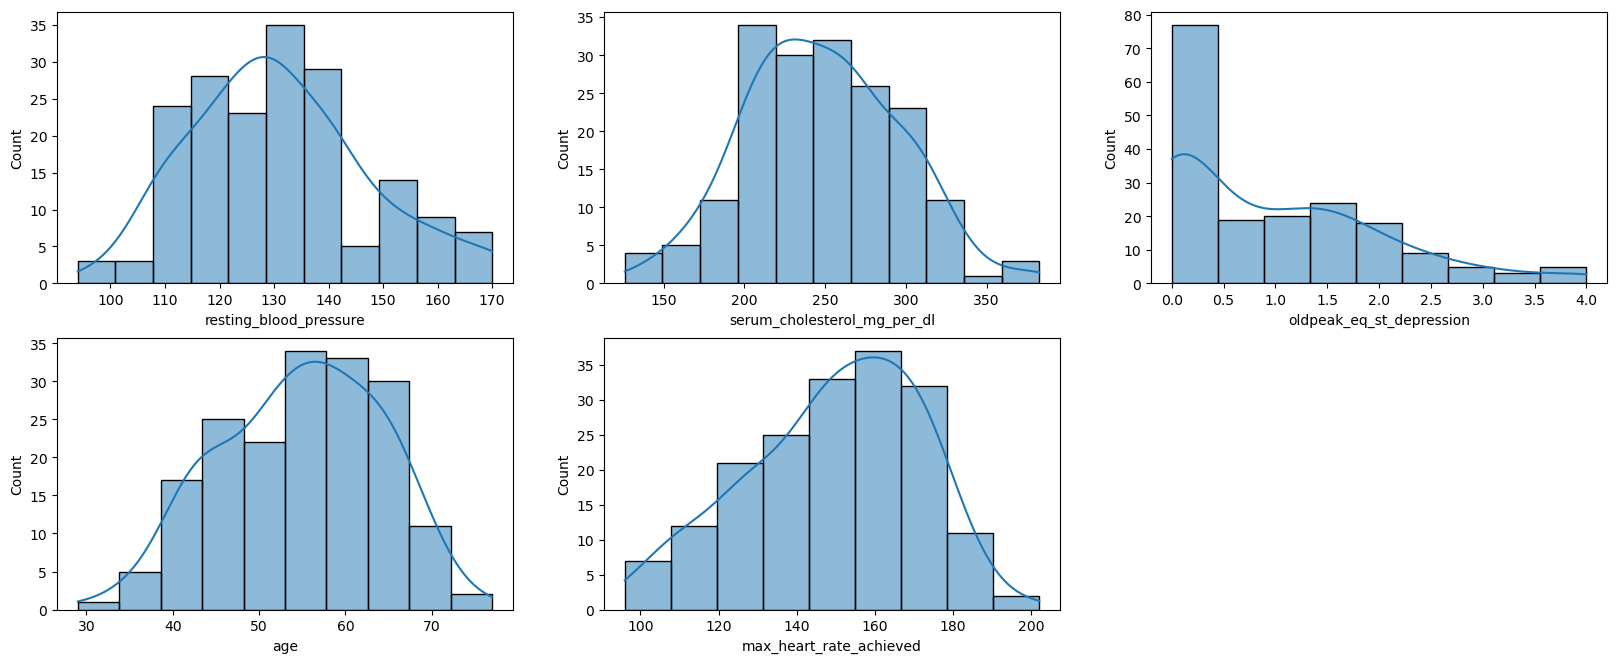

In [31]:
plt.figure(figsize = (20,12))
for i, col in enumerate(continous_cols,1):
    plt.subplot(3,3,i)
    sns.histplot(data = data[col], kde = True)
plt.show()

In [32]:
data["oldpeak_eq_st_depression"] = np.log1p(data["oldpeak_eq_st_depression"])

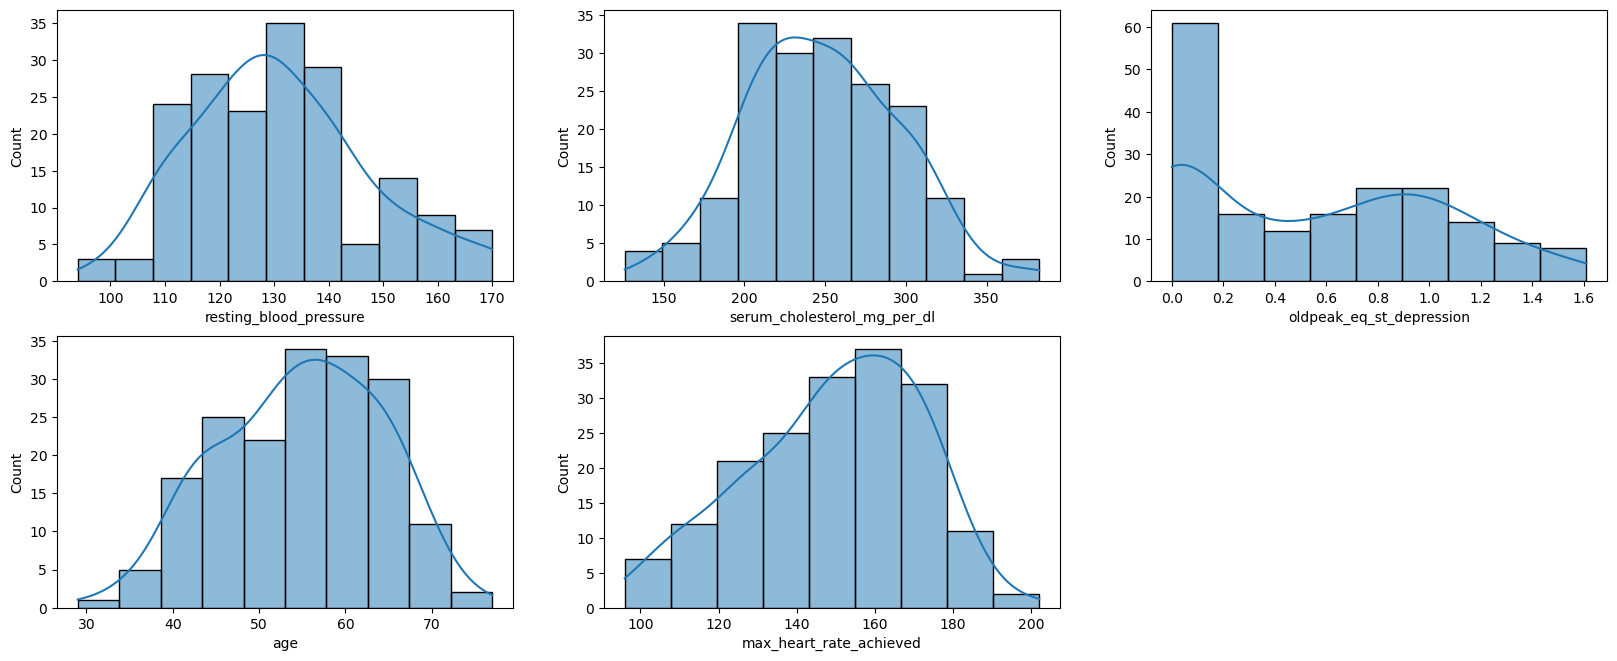

In [33]:
plt.figure(figsize = (20,12))
for i, col in enumerate(continous_cols,1):
    plt.subplot(3,3,i)
    sns.histplot(data = data[col], kde = True)
plt.show()

In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 16 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   slope_of_peak_exercise_st_segment     180 non-null    int64  
 1   resting_blood_pressure                180 non-null    int64  
 2   chest_pain_type                       180 non-null    int64  
 3   num_major_vessels                     180 non-null    int64  
 4   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 5   resting_ekg_results                   180 non-null    int64  
 6   serum_cholesterol_mg_per_dl           180 non-null    float64
 7   oldpeak_eq_st_depression              180 non-null    float64
 8   sex                                   180 non-null    int64  
 9   age                                   180 non-null    int64  
 10  max_heart_rate_achieved               180 non-null    int64  
 11  exercise_induced_an

In [35]:
data.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.044444,3.155556,0.694444,0.161111,1.050000,248.011111,0.560340,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,16.313213,0.938454,0.969347,0.368659,0.998742,47.595918,0.498129,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.587787,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,0.955511,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,170.000000,4.000000,3.000000,1.000000,2.000000,382.500000,1.609438,1.000000,77.000000,202.000000,1.000000,1.000000


In [36]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [37]:
from sklearn.preprocessing import StandardScaler
std = StandardScaler()
x_train = std.fit_transform(x_train)
x_test = std.transform(x_test)


In [38]:
# Observation:
# Features are on very different scales — for example, cholesterol
# is in the 100s-300s while oldpeak is only 0-4.

# Decision:
# I used StandardScaler to scale the features after splitting into
# train and test sets.

# Reason:
# Models like KNN and SVM calculate distance between points, so
# large-range features (like cholesterol) would unfairly dominate
# over small-range features if not scaled. Scaling puts everything
# on the same level for a fair comparison.

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


model1 = LogisticRegression()


model1.fit(x_train, y_train)

y_pred = model1.predict(x_test)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.8333333333333334
Precision: 0.9375
Recall   : 0.75
F1 Score : 0.8333333333333334

Classification Report
              precision    recall  f1-score   support

           0       0.75      0.94      0.83        16
           1       0.94      0.75      0.83        20

    accuracy                           0.83        36
   macro avg       0.84      0.84      0.83        36
weighted avg       0.85      0.83      0.83        36



In [40]:
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier(
    n_estimators=150,
    random_state=42
)

model2.fit(x_train, y_train)

y_pred = model2.predict(x_test)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.8611111111111112
Precision: 1.0
Recall   : 0.75
F1 Score : 0.8571428571428571

Classification Report
              precision    recall  f1-score   support

           0       0.76      1.00      0.86        16
           1       1.00      0.75      0.86        20

    accuracy                           0.86        36
   macro avg       0.88      0.88      0.86        36
weighted avg       0.89      0.86      0.86        36



In [41]:
f_imp = list(model2.feature_importances_)
for imp in f_imp:
    print(imp * 100, end = ", ")
fimp = pd.DataFrame({
    "Columns": x.columns,
    "Importance": model2.feature_importances_
})
fimp.sort_values(by = "Importance", ascending = True)

4.637949765698143, 7.267947103003667, 10.877814976986835, 9.511813781580278, 1.0673559175067437, 2.094741045492019, 8.077256721062636, 11.243320030753615, 2.6367925942891035, 9.402791022833677, 9.817587149878584, 7.897920836809071, 0.5443750008118303, 7.022615680689056, 7.899718372604744, 

,Columns,Importance
12,thal_fixed_defect,0.005444
4,fasting_blood_sugar_gt_120_mg_per_dl,0.010674
5,resting_ekg_results,0.020947
8,sex,0.026368
0,slope_of_peak_exercise_st_segment,0.046379
13,thal_normal,0.070226
1,resting_blood_pressure,0.072679
11,exercise_induced_angina,0.078979
14,thal_reversible_defect,0.078997
6,serum_cholesterol_mg_per_dl,0.080773


In [42]:
 # x.drop(columns = ["thal_fixed_defect"],inplace = True)

In [43]:

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [44]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

model3 = DecisionTreeClassifier(
    random_state=42
)

model3.fit(x_train, y_train)

y_pred = model3.predict(x_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.8333333333333334
Precision: 1.0
Recall   : 0.7
F1 Score : 0.8235294117647058

Classification Report
              precision    recall  f1-score   support

           0       0.73      1.00      0.84        16
           1       1.00      0.70      0.82        20

    accuracy                           0.83        36
   macro avg       0.86      0.85      0.83        36
weighted avg       0.88      0.83      0.83        36



In [45]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
x_scaled = std.fit_transform(x) 

x_train, x_test, y_train, y_test = train_test_split(x_scaled,y, test_size = 0.2, random_state = 42)
model4 = KNeighborsClassifier(
    n_neighbors=5
)

model4.fit(x_train, y_train)

y_pred = model4.predict(x_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.8333333333333334
Precision: 0.9375
Recall   : 0.75
F1 Score : 0.8333333333333334

Classification Report
              precision    recall  f1-score   support

           0       0.75      0.94      0.83        16
           1       0.94      0.75      0.83        20

    accuracy                           0.83        36
   macro avg       0.84      0.84      0.83        36
weighted avg       0.85      0.83      0.83        36



In [46]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

model5 = SVC(
    kernel="rbf",
    C=1.0,
    random_state=42
)

model5.fit(x_train, y_train)

y_pred = model5.predict(x_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.8611111111111112
Precision: 1.0
Recall   : 0.75
F1 Score : 0.8571428571428571

Classification Report
              precision    recall  f1-score   support

           0       0.76      1.00      0.86        16
           1       1.00      0.75      0.86        20

    accuracy                           0.86        36
   macro avg       0.88      0.88      0.86        36
weighted avg       0.89      0.86      0.86        36



In [47]:
from sklearn.model_selection import cross_val_score
print("SVM:", cross_val_score(model5, x_scaled, y, cv=4).mean())
print("Random Forest:", cross_val_score(model2, x, y, cv=4).mean())

SVM: 0.7777777777777778
Random Forest: 0.7944444444444445


In [48]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Decision Tree", "KNN", "SVM"],
    "Accuracy": [0.833, 0.861, 0.806, 0.833, 0.861],
    "Precision": [0.938, 1.000, 0.933, 0.938, 1.000],
    "Recall": [0.750, 0.750, 0.700, 0.750, 0.750],
    "F1 Score": [0.833, 0.857, 0.800, 0.833, 0.857]
})

model_comparison = model_comparison.sort_values(by="F1 Score", ascending=False)
model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest,0.861,1.000,0.75,0.857
4,SVM,0.861,1.000,0.75,0.857
0,Logistic Regression,0.833,0.938,0.75,0.833
3,KNN,0.833,0.938,0.75,0.833
2,Decision Tree,0.806,0.933,0.70,0.800


In [52]:
# Conclusion:
# All 5 models were tested. SVM and Random Forest both scored highest on
# the test data (86% accuracy, 100% precision, 75% recall). To break the
# tie, I used cross-validation, which tests the model on multiple splits
# instead of just one. Random Forest scored higher on average (77% vs 79%),
# making it the more stable and reliable choice for production use.

In [50]:
# Challenges Faced:

# 1. Small dataset (only 180 patients) - results can change a lot depending
#    on the test split, so I used cross-validation for a fairer comparison.

# 2. Two models tied on test results - Random Forest and SVM scored the
#    same, so I used cross-validation to find which one is more consistent.

In [53]:
import pickle
with open("best_model_rf.pkl", "wb") as file:
    pickle.dump(model2, file)